In [1]:
import os
import sys
repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

import numpy as np
import matplotlib.pyplot as plt
from utils import load_yaml, convert_weight_to_tensor
from tqdm import tqdm

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

from data_generation.differential_equations import PoissonSetup2LeastSquares
from train.train_loss import SurrogateLoss
import torch

----------------------------------------
2025-12-11 17:09:22 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup2/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup2/config_data/config_function_space.yaml"
function_space_finer_config_path = repo_path + "/configs/poisson_setup2/config_data/config_function_space_finer.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup2/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup2/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup2/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
function_space_finer_args = load_yaml(function_space_finer_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)

In [3]:
num_basis_list = [2**i for i in range(10)]
print(f'num basis list: {num_basis_list}')

num basis list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [4]:
num_samples = 500
compute_squared_hdiv_h1_norm = poisson_least_squares.compute_squared_hdiv_h1_norm
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

In [5]:
reduced_basis_mse_error_record = np.zeros((len(num_basis_list), num_samples))

In [6]:
sigma_u_dof = np.load(test_dataset_path+'/sigma_u_dof.npy')[:num_samples]
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']] 
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:num_samples]

In [7]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    reduced_basis_sigma_u_dof = reference_reduced_minimizers[:, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(num_samples))):
        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()

        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = reduced_basis_sigma_u_dof[j]
        sigma_label_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_label_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()

        reduced_basis_mse_error_record[i, j] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_label_low_rank_fc, u_label_fc - u_label_low_rank_fc)

100%|██████████| 10/10 [02:27<00:00, 14.78s/it]


In [8]:
mean_reduced_basis_mse_error_record = np.mean(reduced_basis_mse_error_record, axis=1)

In [9]:
mean_reduced_basis_mse_error_record

array([0.90103183, 0.47255435, 0.25403069, 0.13944026, 0.07127429,
       0.03580656, 0.01764075, 0.00915824, 0.0051884 , 0.00340937])

## RB loss

In [10]:
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:,:output_reduced_basis_args['num_basis']]

In [11]:
dtype = torch.float64

In [12]:
pod_basis_dof = torch.tensor(pod_basis_dof, dtype=dtype)
reference_reduced_minimizers  = torch.tensor(reference_reduced_minimizers , dtype=dtype)
quadratic_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_quadratic_weight.npy'), dtype=dtype)
linear_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_linear_weight.npy'), dtype=dtype)
bias = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_bias.npy'), dtype=dtype)

In [13]:
reduced_weight_list = []
for i in range(len(quadratic_weight)):
    reduced_weight = {}
    reduced_weight['quadratic'] = quadratic_weight[i]
    reduced_weight['linear'] = linear_weight[i]
    reduced_weight['bias'] = bias[i]
    reduced_weight_list.append(reduced_weight)

In [14]:
surrogate_loss = SurrogateLoss(reduced_weight_list)

In [15]:
num_samples = 500
num_basis_list = [2**i for i in range(10)]
print("num_basis_list:", num_basis_list)
reference_surrogate_loss_record = np.zeros((len(num_basis_list), num_samples))

num_basis_list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [16]:
for i, num_basis in enumerate(num_basis_list):
    for j, sample_index in enumerate(range(num_samples)):
        reference_loss = surrogate_loss(reference_reduced_minimizers[sample_index], sample_index, sub_dim=num_basis)
        reference_surrogate_loss_record[i, j] = reference_loss.item()

In [17]:
mean_reference_surrogate_loss_record = np.mean(reference_surrogate_loss_record, axis=1)

## FE loss

In [18]:
p_dof = np.load(test_dataset_path+'/p_dof.npy')[:num_samples]

In [19]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [20]:
reference_loss_list = []
for i in tqdm(range(num_samples)):
    p_fc = dolfinx.fem.Function(Vh['p'], dtype='float64')  
    p_fc.x.array[:] = p_dof[i]
    weight = poisson_least_squares.compute_weight(p_fc)
    weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])

    y = sigma_u_dof[i]
    y = torch.tensor(y, dtype=torch_dtype['float64'])
    reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'reference loss: {reference_loss.item()}')
    reference_loss_list.append(reference_loss.item())

  0%|          | 1/500 [00:02<21:38,  2.60s/it]

reference loss: 0.004004289087475854


  0%|          | 2/500 [00:04<17:15,  2.08s/it]

reference loss: 0.004005698777149291


  1%|          | 3/500 [00:06<15:45,  1.90s/it]

...

reference loss: 0.004005722013403101


100%|█████████▉| 499/500 [14:52<00:01,  1.89s/it]

reference loss: 0.004004958463212915


100%|██████████| 500/500 [14:54<00:00,  1.79s/it]

reference loss: 0.0040039483762370764


In [21]:
loss_diff = mean_reference_surrogate_loss_record - np.mean(reference_loss_list).item()

In [22]:
loss_diff

array([1.47271304, 0.61887659, 0.33385674, 0.17958967, 0.08471378,
       0.04116213, 0.02009807, 0.01019533, 0.00528878, 0.00289187])

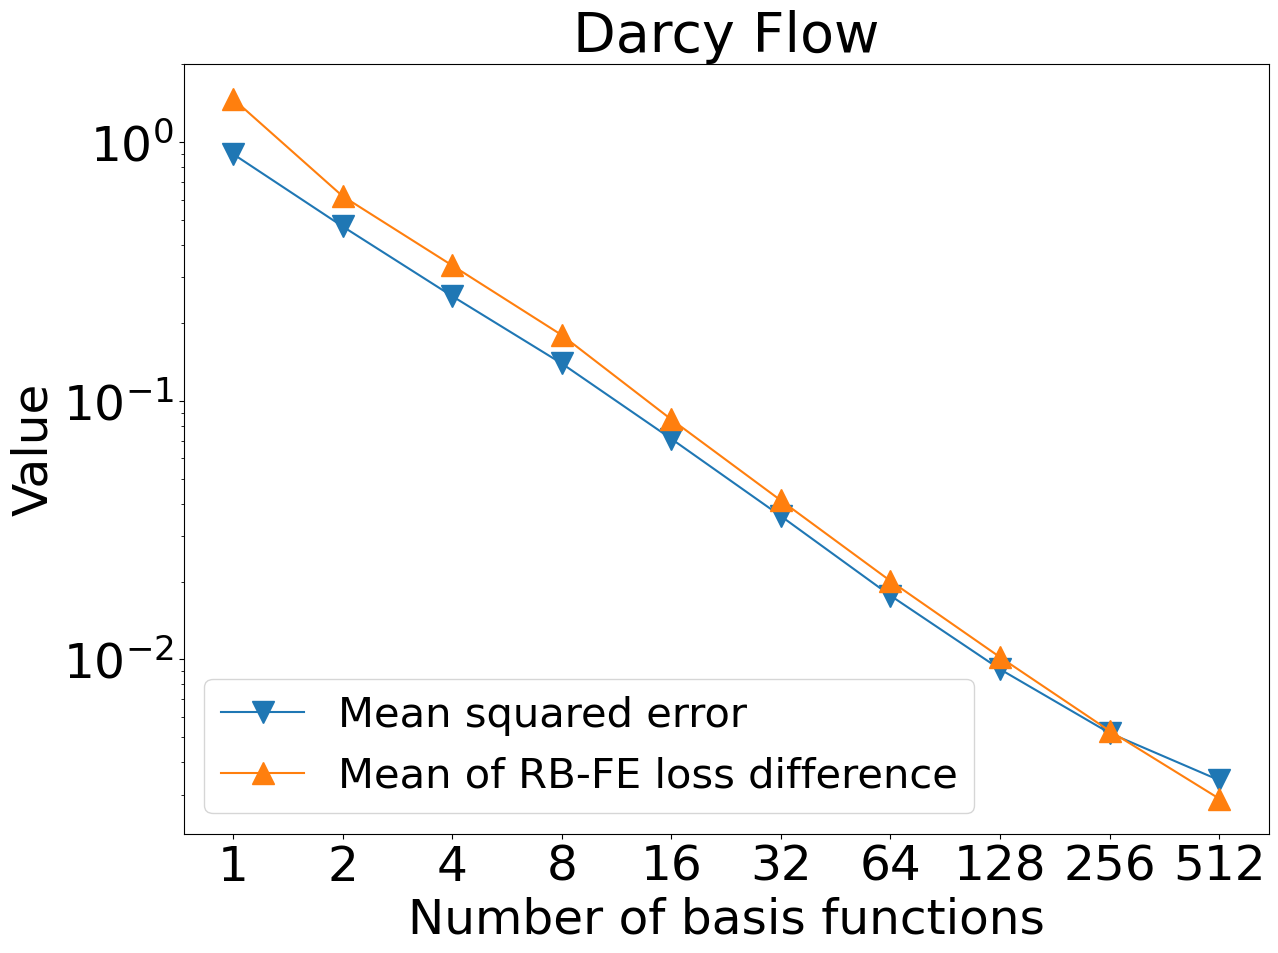

In [23]:
plt.figure(figsize=(14,10))
plt.plot(num_basis_list, mean_reduced_basis_mse_error_record, marker='v', markersize=16, label='Mean squared error')
plt.plot(num_basis_list, loss_diff, marker='^', markersize=16, label='Mean of RB-FE loss difference')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of basis functions', fontsize=35)
plt.ylabel('Value',fontsize=35)
plt.xticks(num_basis_list, num_basis_list, fontsize=35)
plt.yticks(fontsize=35)
plt.legend(fontsize=30, loc='lower left')
plt.title('Darcy Flow', fontsize=40)
plt.savefig(os.path.join(test_dataset_path, "analysis_loss_diff_and_mse_error.png"), dpi=300, bbox_inches='tight')
plt.show()